# 멀티모달 RAG
모달리티는 이미지, 텍스트, 음성 등 입력받거나 처리하는 데이터의 형태를 의미하며 멀티모달은 이러한 서로 다른 유형의 데이터를 동시에 사용하는 방식을 뜻한다.  
## 멀티모달 RAG 
- 멀티모달 RAG는 단순 텍스트 정보에 의존하는 것이 아니라 이미지, 차트, 테이블 등의 시각적 구조적 데이터까지 포함하여 정보를 포함하고 생성하는 기법이다. 
### 멀티 모달 RAG 구현 방법 
- 모든 모달리티를 동일한 벡터 공간에 포함하기 
- 모든 모달리티를 하나의 기본 모달리티로 묶기 
- 서로 다른 모달리티를 별도의 저장소에서 다루기 

In [5]:
import nltk
from unstructured.partition.pdf import partition_pdf 
import os 



In [6]:
fname = './data/sample.pdf'
fpath = './data' 

In [8]:
raw_pdf_elements = partition_pdf(
    filename= fname,
    extract_images_in_pdf= True, 
    infer_table_structure=True, 
    chunking_strategy="by_title", 
    extract_image_block_output_dir=fpath
)

No languages specified, defaulting to English.
Loading weights: 100%|██████████| 367/367 [00:00<00:00, 20218.16it/s]


In [10]:
tables = []
texts = []

In [12]:
for element in raw_pdf_elements:
    if "unstructured.documents.elements.Table" in str(type(element)):
        tables.append(str(element))
    elif "unstructured.documents.elements.CompositeElement" in str(type(element)):
        texts.append(str(element))

In [13]:
tables[0]

'2022년 2023년 2020년 2024년 42주 2021년 747 294 전체 420 385 665 356 274 630 382 673 국내발생 74 20 해외유입 35 29 38'

In [ ]:
texts[0]   

'42주차 (10.13.~10.19.)\n\n2 e FR | May | Suey | aieicel\n\n국내발생 해외유입\n\n전체\n\n주차'

In [15]:
from langchain_core.output_parsers import StrOutputParser 
from langchain_core.prompts import ChatPromptTemplate 
from langchain_openai import ChatOpenAI 


In [16]:
prompt_text = """
    당신은 표와 텍스트를 요약하여 검색할 수 있도록 돕는 역할을 맡은 어시스턴트 입니다. 
    이 요약은 임베딩 되어 원본 텍스트나 표 요소를 검색하는데 사용될 것입니다. 
    표 또는 텍스트에 대한 간결한 요약을 제공하여 검색에 최적화된 형태로 만들어주세요. 
    표 또는 텍스트 : {element} """ 

prompt = ChatPromptTemplate.from_template(prompt_text)

In [17]:
model = ChatOpenAI(
    model="gemma-3-4b-it",
    base_url="http://localhost:1234/v1",
    api_key="lm-studio"
)

summarize_chain = {"element" : lambda x : x} | prompt | model | StrOutputParser()

In [18]:
text_summaries = summarize_chain.batch(texts, {"max_concurrency" : 3})

In [19]:
tables_summaries = summarize_chain.batch(tables, {"max_concurrency" : 3})

In [20]:
tables_summaries[0]

'제공해주신 데이터는 여러 해와 주차별 사례를 비교한 표의 일부로 보입니다. 정보가 압축되어 있어, 검색에 최적화되도록 **주요 구성 요소**와 **연도별/기간별 추이**를 명확하게 구분하여 정리했습니다.\n\n이 요약은 원본 표의 데이터를 정확히 검색하고 필요한 정보를 빠르게 찾을 수 있도록 하는 것을 목표로 합니다.\n\n***\n\n### 🔍 데이터 요약 및 검색 최적화 (Summary for Retrieval)\n\n#### 1. 데이터 개요\n이 자료는 다수의 연도(2020년, 2021년, 2022년, 2023년 등) 및 특정 기간(42주) 동안의 전체 사례 수, 그리고 그 중 국내 발생분과 해외 유입분을 비교한 통계입니다.\n\n#### 2. 주요 수치 및 구성 요소 (Key Figures & Components)\n| 구분 | 항목/기간 | 세부 수치 (예시적 배치) | 검색 키워드 |\n| :--- | :--- | :--- | :--- |\n| **전체 발생** | 기간별 총합 | 673, 382 등 (주요 합계) | 전체 사례 수, 총 발생액 |\n| **기간 단위** | 42주 | [특정 주차 관련 수치] | 42주차 추이, 해당 기간 발생률 |\n| **국내발생** | 국내 발생 사례 수 | 74, 20 등 (주요 발생 건수) | 국내 유행 동향, 본토 확진자 수 |\n| **해외유입** | 해외 유입 사례 수 | 35, 29, 38 등 (주요 도입 건수) | 해외 경로 유입 사례, 국경 검역 수치 |\n\n#### 3. 연도별 추이 (Temporal Trends)\n*   **2021년 데이터:** [특정 수치] 발생 (전체적으로 높은 수치를 나타냄)\n*   **2022년 데이터:** [특정 수치] 발생 (중간 단계의 추이)\n*   **2023년 데이터:** [특정 수치] 발생 (최신 또는 특정 시점의 추이)\n*   **2024년 데이터:** [특정 수치] 발생 (가장 최신 또는 비교 대상)\n\n***\n*(**참고:** 제공된 데

In [21]:
text_summaries[0]

'이 표는 특정 기간 동안의 발생 건수 또는 상황을 **발생 경로(국내 vs. 해외)** 및 **종합 현황**에 따라 정리한 주간 보고서의 일부로 보입니다.\n\n다음은 검색 및 임베딩에 최적화된 두 가지 유형의 요약입니다.\n\n---\n\n### 🔍 옵션 1: 간결 키워드 요약 (검색 시 가장 효율적)\n\n**주차:** 42주차 (10.13.~10.19.)\n**내용:** 발생 건수 추적 및 분석 보고서 (주차별)\n**핵심 분류:** 국내 발생 건, 해외 유입 건, 전체 현황\n\n***\n\n### 📋 옵션 2: 구조화된 필드 요약 (데이터베이스 입력 시 적합)\n\n| 분류 항목 | 내용 |\n| :--- | :--- |\n| **보고 기간** | 42주차 (10.13.~10.19.) |\n| **데이터 유형** | 발생 건수/현황 보고서 |\n| **주요 구분 항목** | 국내발생, 해외유입, 전체 (Total), 주차별 추이 |\n| **열 제목 (추정)** | [데이터 불명확: 2 e FR, May, Suey, aieicel] |'

#### 이미지 요약

In [22]:
import base64 

def encode_image(image_path) -> str:
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

img_base64_list = [] 


for img_file in sorted(os.listdir(fpath)):
    if img_file.endswith('.jpg'):
        img_path = os.path.join(fpath, img_file)
        base64_image = encode_image(img_path)
        img_base64_list.append(base64_image)

In [23]:
from langchain_core.messages import HumanMessage 
from langchain_openai import ChatOpenAI 

def image_summarize(img_base64: str) -> str:

    chat = ChatOpenAI(
        model="gemma-3-4b-it",
        base_url="http://localhost:1234/v1",
        api_key="lm-studio", 
        max_tokens=1024)
    
    prompt = """
    당신은 이미지를 요약하여 검색을 위해 사용할 수 있도록 돕는 어시스턴트입니다.
    이 요약은 임베딩되어 원본 이미지를 검색하는 데 사용됩니다.
    이미지 검색에 최적화된 간결한 요약을 작성하세요.
    """
    msg = chat.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{img_base64}"
                        },
                    },
                ]
            )
        ]
    )
    return msg.content



In [27]:
image_summaries = []

for img_base64 in img_base64_list:
    image_summary = image_summarize(img_base64)
    image_summaries.append(image_summary)
    

In [28]:
len(image_summaries)

43

In [29]:
image_summaries[0]

"이 이미지는 질병관리청(KDCA)에서 발행한 **'2024년 말라리아 주간 감시 보고서'**의 표지입니다. 검색에 최적화된 요약은 다음과 같습니다.\n\n***\n\n### 🔍 Image Summary for Search Indexing (Concise)\n\n**KDCA's Weekly Malaria Surveillance Report, 2024.**\n(Specific issue: Week 42, covering October 13–October 19.)\n\n### 🏷️ Metadata Tags (For Retrieval)\n\n*   Malaria\n*   KDCA\n*   질병관리청\n*   Weekly Report / 주간 보고서\n*   2024년\n*   Malaria Surveillance (말라리아 감시)\n*   Week 42"

#### 벡터 저장소에 추가 

In [34]:
from langchain_classic.retrievers import MultiVectorRetriever
from langchain_core.stores import InMemoryStore 
from langchain_openai import OpenAIEmbeddings 
from langchain_community.vectorstores import Chroma 

import chromadb
client = chromadb.HttpClient(
    host="localhost",
    port=8000,
    tenant="default_tenant",
    database="default_database",
)

print(client.heartbeat())


1782632378044909711


In [35]:

embedding_function = OpenAIEmbeddings(
    model="bge-m3",
    base_url="http://localhost:1234/v1",
    api_key="lm-studio",
    check_embedding_ctx_length=False,
)



In [36]:
collection_name = "multi_modal_rag"

try:
    client.delete_collection(collection_name)
except Exception:
    pass


vectorstore = Chroma(
    collection_name=collection_name,
    embedding_function=embedding_function,
    client=client,
)


/var/folders/kc/qm9ykcl12cv910wgvjsx9hs40000gn/T/ipykernel_67709/1206770217.py:9: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


In [37]:

docstore = InMemoryStore()
id_key = "doc_id"

retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=docstore,
    id_key=id_key,
)

In [38]:
import uuid

doc_ids = [str(uuid.uuid4()) for _ in texts]
retriever.docstore.mset(list(zip(doc_ids, texts)))

table_ids = [str(uuid.uuid4()) for _ in tables]
retriever.docstore.mset(list(zip(table_ids, tables)))

img_ids = [str(uuid.uuid4()) for _ in img_base64_list]
retriever.docstore.mset(list(zip(img_ids, img_base64_list)))

In [ ]:
from langchain_core.documents import Document

summary_texts = [
    Document(page_content=s, metadata={id_key: doc_ids[i]})
    for i, s in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)

summary_tables = [
    Document(page_content=s, metadata={id_key: table_ids[i]})
    for i, s in enumerate(tables_summaries)
]
retriever.vectorstore.add_documents(summary_tables)


summary_img = [
    Document(page_content=s, metadata={id_key: img_ids[i]})
    for i, s in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)

['307e3b37-3312-4df0-abca-b340720b1020',
 '8a70c83e-a9f6-4b88-bff5-2f544a199c7a',
 'a622af37-a6b1-4504-bc80-79b10dabd5b9',
 '8f8875bb-12c4-41cc-a0a9-df93397c8200',
 '3c98b1ca-4815-44e7-8d10-85bf231df10f',
 '4f59f066-7704-4fab-9ca4-60c58eb535d2',
 '9f095d61-d986-44e8-aa5c-9369e7243e3e',
 '64cebf6c-05f5-4e5c-bff5-60cfd2ca8eb8',
 '5495ff3b-b5da-49f8-8b0d-4bc0db4ad2c4',
 '7c48652b-2a0b-405a-9007-3a9a75ca1cf0',
 '7cbe5392-baa4-44f9-b62e-057c09644b8a',
 '969aac12-1f6f-4dce-b879-5a544452a0c6',
 'c9d05c2d-5cc3-43c8-900d-b6d7c8caca0d',
 '058d31d5-ef93-44ad-aaed-3038b7319a36',
 'ae0240bf-ff17-4e32-a48e-cb1272d5c5d3',
 'bdf51212-95b6-427d-a612-13533ea649d8',
 '2db0a2b8-63c4-4a6b-94cd-fed4150fd050',
 'ea186964-ea65-4105-b829-b3f9a3d85ab7',
 '4095e786-a62f-4a37-978f-b50c2215a0a7',
 'b4fa70a9-314e-4c1d-ab90-fb51383ea00c',
 '69d3f801-228d-4263-844c-f9a6145ebf65',
 '663da3ab-ae46-4a13-908f-91f4b31d2eb3',
 '3c2df259-d883-4898-988c-3947ace14abf',
 'a73403f5-4ecf-4b59-9d76-cdbfbd00d571',
 'eb01982c-73da-

In [40]:
docs = retriever.invoke(
    "말라리아 군집 사례는 어떤가요? "
)

In [41]:
print(len(docs))

4


In [42]:
from base64 import b64decode

def split_image_text_types(docs):
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {
        "images": b64,
        "texts": text
    }

docs_by_type = split_image_text_types(docs)

In [43]:
len(docs_by_type["images"])

2

In [44]:

len(docs_by_type["texts"])

2

In [45]:
docs_by_type["images"][0][:100]

'/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAx'

In [46]:

docs_by_type["texts"]

['42주차 (10.13.~10.19.) 3 말라리아 군집사례 현황 - (누적) 4개 시도(경기, 서울, 인천, 강원), 총 46건의 군집사례* 확인 * 군집사례 : 위험지역 내에서 2명 이상의 환자가 증상 발생 간격이 14일 이내, 환자 거주지 거리가 1Km 이내인 경우 표6 군집사례 발생 현황 시군구 발생(군집사례건수) 시·도 사례건수(환자수) 4개 시도 46건(114명) 합계 ▸5명 군집(1) : 양천구, 강서구(1) 서울 1건(5명) ▸2명 군집(5) : 서구(2), 강화군(1), 연수구(1), 중구(1) 5건(10명) 인천 ▸6명 군집(1) : 파주시(1) ▸4명 군집(3) : 파주시(2), 김포시(1), ▸3명 군집(6) : 파주시(4), 김포시(1), 일산서구(1) 39건(94명) 경기 ▸2명 군집(29) : 파주시(15), 김포시(10), 일산동구(2), 일산서구(1), 연천군(1) ▸5명 군집(1) : 철원군(1) 1건(5명) 강원 그림 6. 군집사례 6',
 '42주차 (10.13.~10.19.)\n\n3 말라리아 군집사례 현황\n\n* 군집사례 : 위험지역 내에서 2명 이상의 환자가 증상 발생 간격이 14일 이내, 환자 거주지 거리가 1Km 이내인 경우\n\n그림 6. 군집사례\n\n6']


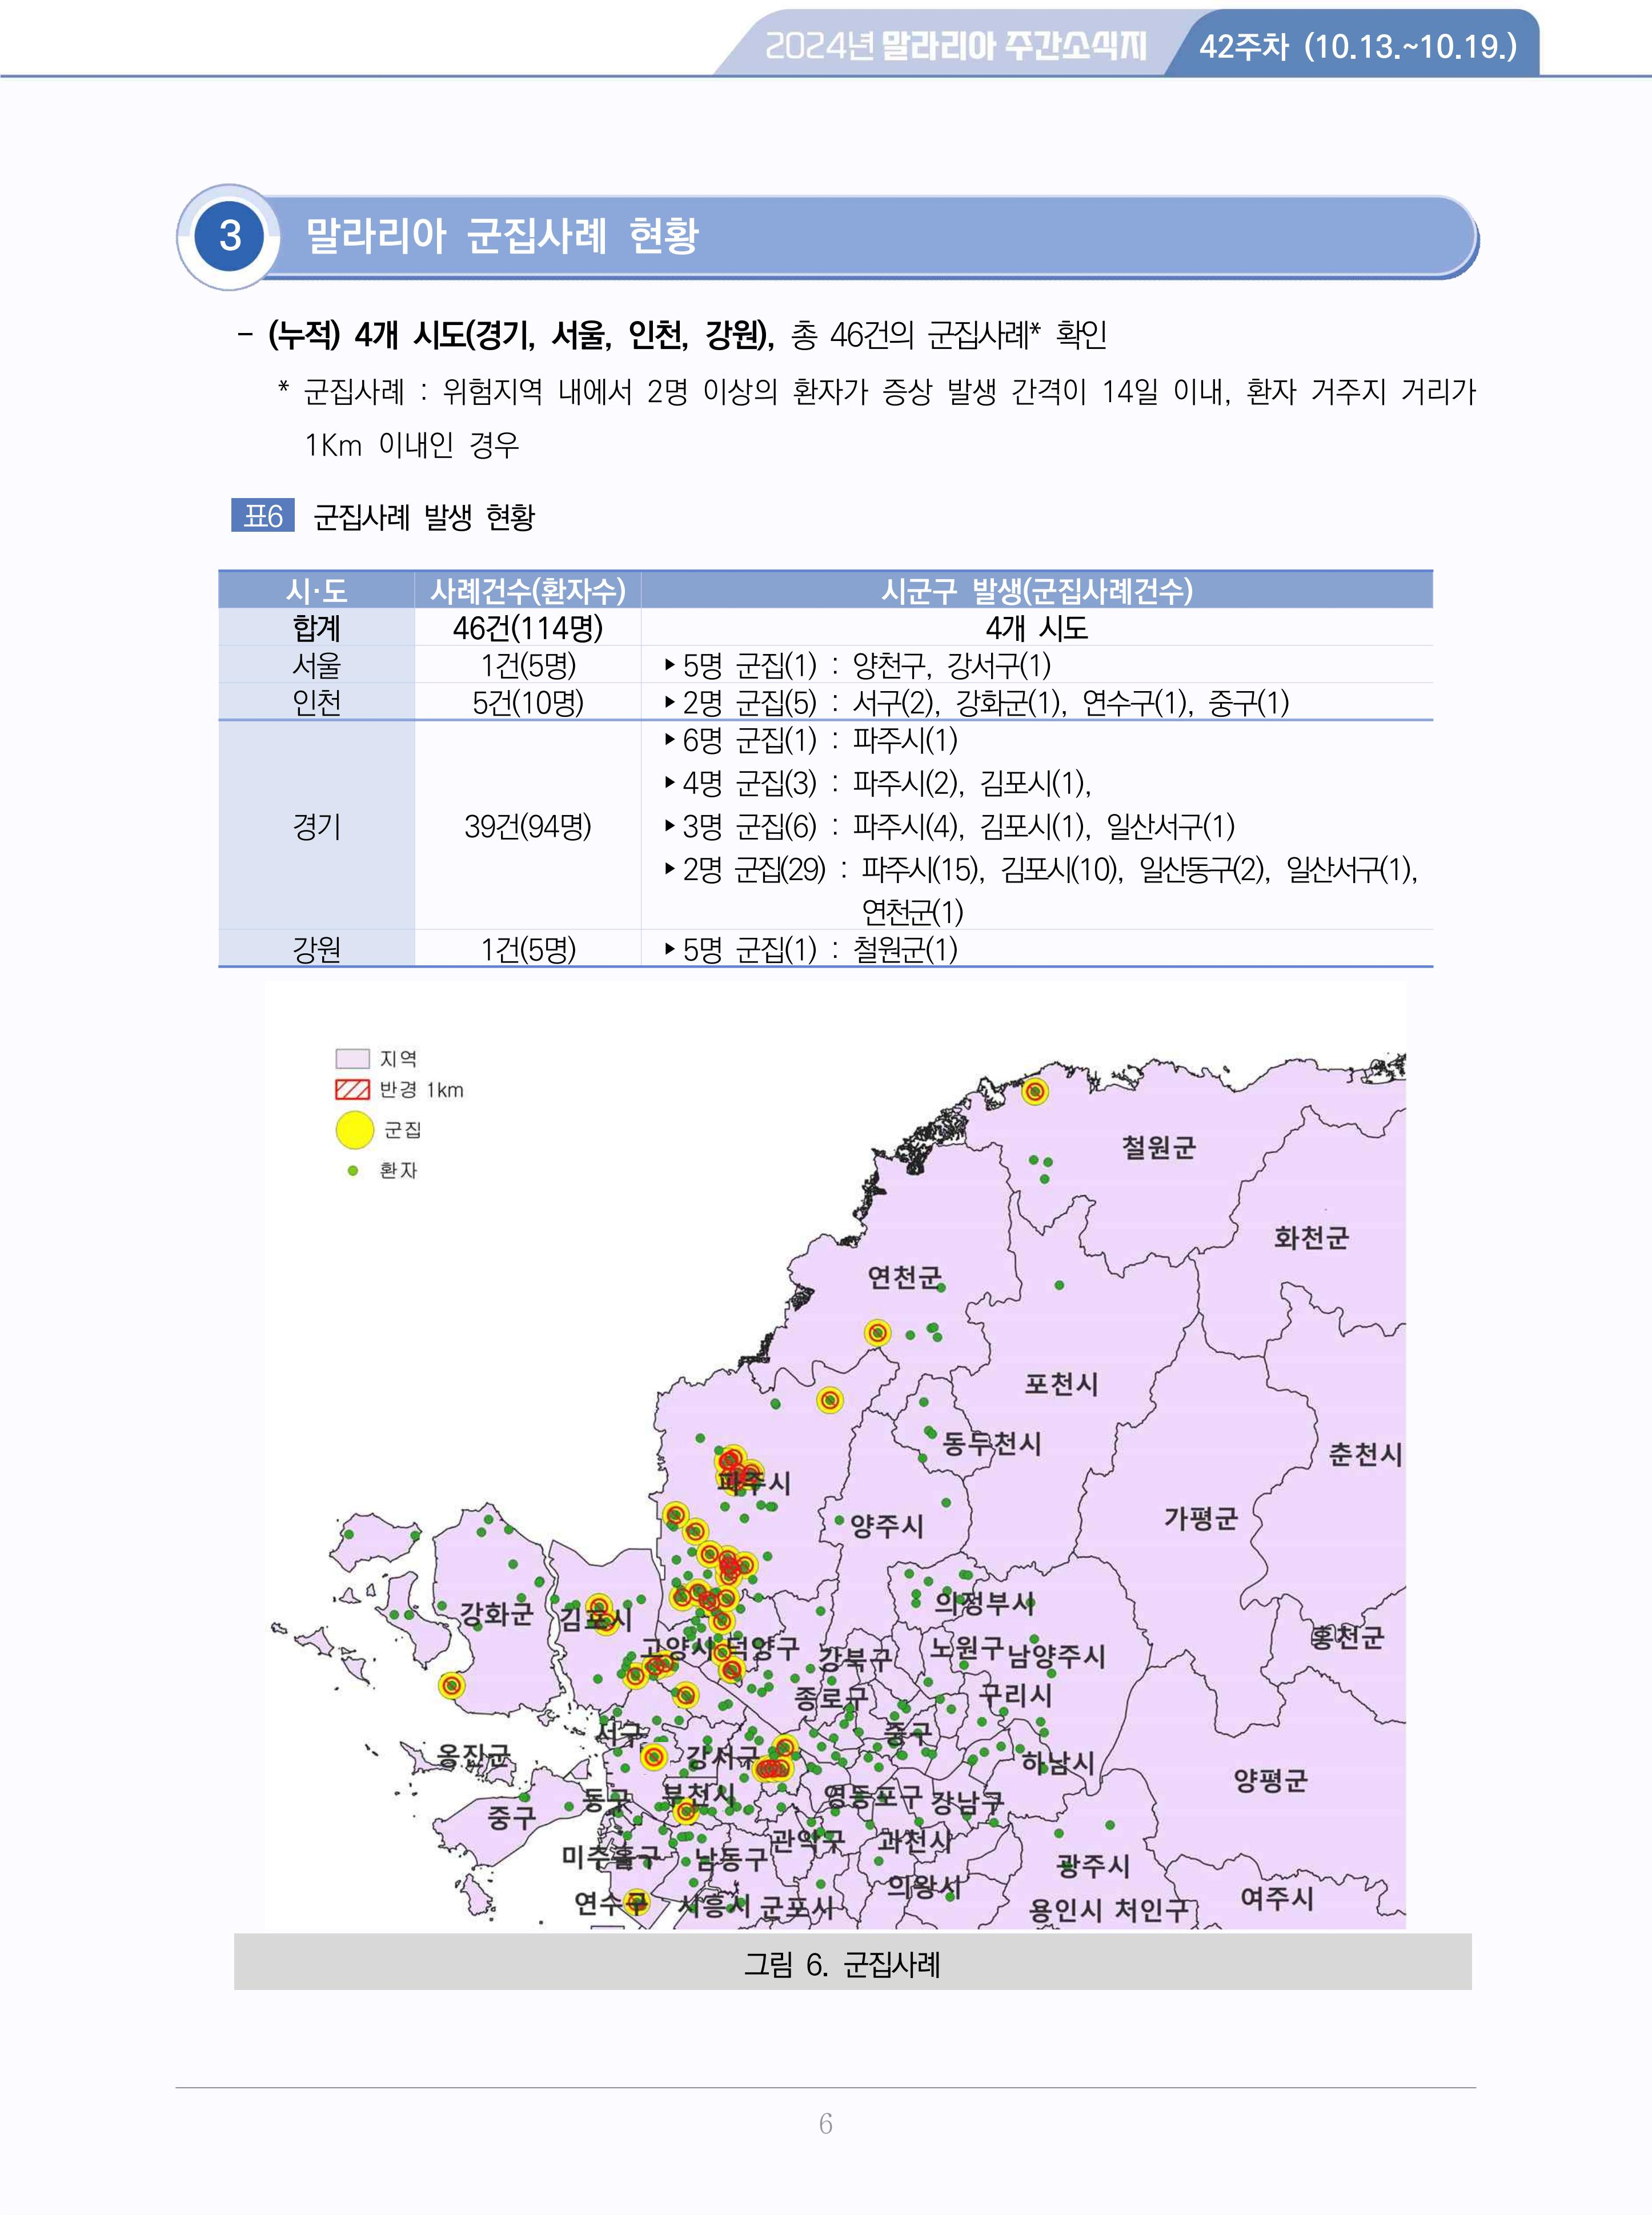

In [48]:
from IPython.display import display, HTML

def plt_img_base64(img_base64):
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    display(HTML(image_html))

plt_img_base64(docs_by_type["images"][0])

In [49]:
docs_by_type["texts"][0]

'42주차 (10.13.~10.19.) 3 말라리아 군집사례 현황 - (누적) 4개 시도(경기, 서울, 인천, 강원), 총 46건의 군집사례* 확인 * 군집사례 : 위험지역 내에서 2명 이상의 환자가 증상 발생 간격이 14일 이내, 환자 거주지 거리가 1Km 이내인 경우 표6 군집사례 발생 현황 시군구 발생(군집사례건수) 시·도 사례건수(환자수) 4개 시도 46건(114명) 합계 ▸5명 군집(1) : 양천구, 강서구(1) 서울 1건(5명) ▸2명 군집(5) : 서구(2), 강화군(1), 연수구(1), 중구(1) 5건(10명) 인천 ▸6명 군집(1) : 파주시(1) ▸4명 군집(3) : 파주시(2), 김포시(1), ▸3명 군집(6) : 파주시(4), 김포시(1), 일산서구(1) 39건(94명) 경기 ▸2명 군집(29) : 파주시(15), 김포시(10), 일산동구(2), 일산서구(1), 연천군(1) ▸5명 군집(1) : 철원군(1) 1건(5명) 강원 그림 6. 군집사례 6'

In [ ]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
def prompt_func(dict):
    format_texts = "\n".join(dict["context"]["texts"])
    text = f"""
    다음 문맥에만 기반하여 질문에 답하세요. 문맥에는 텍스트, 표, 그리고 아래 이미지가 포함될 수 있습니다:
    질문: {dict["question"]}

    텍스트와 표:
    {format_texts}
    """

    prompt = [
        HumanMessage(
            content=[
                {"type": "text", "text": text},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{dict['context']['images'][0]}"}},
            ]
        )
    ]

    return prompt

chain = (
        {"context": retriever | RunnableLambda(split_image_text_types), "question": RunnablePassthrough()}
        | RunnableLambda(prompt_func)
        | model
        | StrOutputParser()
)

In [52]:

chain.invoke(
    "말라리아 군집 사례는 어떤가요?"
)

'제공된 자료에 따르면, 현재 말라리아 군집 사례는 다음과 같습니다:\n\n**🔍 종합 현황 (누적):**\n\n*   **관련 시도:** 4개 시도 (경기, 서울, 인천, 강원)\n*   **총 군집사례 건수:** 46건\n*   **총 환자 수:** 114명\n\n---\n\n**🗺️ 시·도별 세부 현황 (표 6 기반):**\n\n*   **서울:** 총 1건 (5명)\n    *   양천구, 강서구에서 발생.\n*   **인천:** 총 5건 (10명)\n    *   서구(2), 강화군(1), 연수구(1), 중구(1)에서 발생.\n*   **경기:** 총 39건 (94명)\n    *   파주시(1), 김포시에서 발생한 여러 군집 사례 및 일산 지역, 연천군에서도 발생.\n*   **강원:** 총 1건 (5명)\n    *   철원군에서 발생.\n\n*(참고: 군집사례는 위험지역 내에서 2명 이상의 환자가 증상 발생 간격이 14일 이내, 거주지 거리가 1Km 이내인 경우를 의미합니다.)*'